In [1]:
from google.colab import drive; drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import json
import pandas as pd

file = "/content/drive/MyDrive/All_Beauty.jsonl"


data_list = []
with open(file, 'r') as fp:
    for line in fp:
        data = json.loads(line.strip())
        data_list.append(data)

# Convert to pandas DataFrame
df = pd.DataFrame(data_list)

In [4]:
pd.to_datetime(1589665266052, unit='ms')

Timestamp('2020-05-16 21:41:06.052000')

In [5]:
df.head()

,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,5.0,Such a lovely scent but not overpowering.,This spray is really nice. It smells really go...,[],B00YQ6X8EO,B00YQ6X8EO,AGKHLEW2SOWHNMFQIJGBECAF7INQ,1588687728923,0,True
1,4.0,Works great but smells a little weird.,"This product does what I need it to do, I just...",[],B081TJ8YS3,B081TJ8YS3,AGKHLEW2SOWHNMFQIJGBECAF7INQ,1588615855070,1,True
2,5.0,Yes!,"Smells good, feels great!",[],B07PNNCSP9,B097R46CSY,AE74DYR3QUGVPZJ3P7RFWBGIX7XQ,1589665266052,2,True
3,1.0,Synthetic feeling,Felt synthetic,[],B09JS339BZ,B09JS339BZ,AFQLNQNQYFWQZPJQZS6V3NZU4QBQ,1643393630220,0,True
4,5.0,A+,Love it,[],B08BZ63GMJ,B08BZ63GMJ,AFQLNQNQYFWQZPJQZS6V3NZU4QBQ,1609322563534,0,True


In [6]:
df.columns

Index(['rating', 'title', 'text', 'images', 'asin', 'parent_asin', 'user_id',
       'timestamp', 'helpful_vote', 'verified_purchase'],
      dtype='object')

In [7]:
print(f"Максимальный допустимый timestamp: {pd.Timestamp.max}")
print(f"Максимальный timestamp в секундах: {pd.Timestamp.max.timestamp()}")

Максимальный допустимый timestamp: 2262-04-11 23:47:16.854775807
Максимальный timestamp в секундах: 9223372036.854776


In [8]:
df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms')
df['product_id'] = df['parent_asin']

In [9]:
df.head()

,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase,product_id
0,5.0,Such a lovely scent but not overpowering.,This spray is really nice. It smells really go...,[],B00YQ6X8EO,B00YQ6X8EO,AGKHLEW2SOWHNMFQIJGBECAF7INQ,2020-05-05 14:08:48.923,0,True,B00YQ6X8EO
1,4.0,Works great but smells a little weird.,"This product does what I need it to do, I just...",[],B081TJ8YS3,B081TJ8YS3,AGKHLEW2SOWHNMFQIJGBECAF7INQ,2020-05-04 18:10:55.070,1,True,B081TJ8YS3
2,5.0,Yes!,"Smells good, feels great!",[],B07PNNCSP9,B097R46CSY,AE74DYR3QUGVPZJ3P7RFWBGIX7XQ,2020-05-16 21:41:06.052,2,True,B097R46CSY
3,1.0,Synthetic feeling,Felt synthetic,[],B09JS339BZ,B09JS339BZ,AFQLNQNQYFWQZPJQZS6V3NZU4QBQ,2022-01-28 18:13:50.220,0,True,B09JS339BZ
4,5.0,A+,Love it,[],B08BZ63GMJ,B08BZ63GMJ,AFQLNQNQYFWQZPJQZS6V3NZU4QBQ,2020-12-30 10:02:43.534,0,True,B08BZ63GMJ


In [10]:
# Посмотрим, сколько отзывов на пользователя
user_review_counts = df['user_id'].value_counts()
print(f"Пользователей с >1 отзывом: {(user_review_counts > 1).sum()}")
print(f"Пользователей с >5 отзывами: {(user_review_counts > 5).sum()}")
print(f"Максимум отзывов у одного пользователя: {user_review_counts.max()}")

# Посмотрим распределение
print(user_review_counts.value_counts().sort_index().head(20))

Пользователей с >1 отзывом: 48433
Пользователей с >5 отзывами: 1062
Максимум отзывов у одного пользователя: 165
count
1     583553
2      39274
3       5713
4       1826
5        558
6        351
7        181
8        130
9         70
10        35
11        35
12        26
13        33
14        19
15        20
16        20
17        14
18         6
19         5
20         7
Name: count, dtype: int64


In [11]:
active_users = user_review_counts[user_review_counts >= 3].index
df_active = df[df['user_id'].isin(active_users)].copy()

print(f"После фильтрации: {len(df_active)} отзывов от {len(active_users)} пользователей")

После фильтрации: 39427 отзывов от 9159 пользователей


In [12]:
df_active.head()

,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase,product_id
8,5.0,Great for at home use and so easy to use!,This is perfect for my between salon visits. I...,[],B08P2DZB4X,B08P2DZB4X,AFSKPY37N3C43SOI5IEXEK5JSIYA,2021-07-27 13:04:04.559,0,False,B08P2DZB4X
9,5.0,Nice shampoo for the money,I get Keratin treatments at the salon at least...,[],B086QY6T7N,B086QY6T7N,AFSKPY37N3C43SOI5IEXEK5JSIYA,2021-07-18 13:21:51.145,0,False,B086QY6T7N
10,3.0,Not what I thought I would be getting,I was very disappointed when I got this facial...,[],B08DHTJ25J,B08DHTJ25J,AFSKPY37N3C43SOI5IEXEK5JSIYA,2021-07-13 21:20:45.370,0,False,B08DHTJ25J
11,5.0,A little goes a long way!,This is a really nice moisturizing lotion. It ...,[],B07RBSLNFR,B07RBSLNFR,AFSKPY37N3C43SOI5IEXEK5JSIYA,2021-05-16 17:00:30.697,0,False,B07RBSLNFR
12,3.0,Just ok,I try to get Keratin treatments every 3 months...,[],B07SLFWZKN,B07SLFWZKN,AFSKPY37N3C43SOI5IEXEK5JSIYA,2021-04-29 23:05:01.209,0,False,B07SLFWZKN


In [13]:
# Calculate diff after sorting within the groupby
df_active['time_since_last'] = (
    df_active.sort_values(['user_id', 'timestamp'])
    .groupby('user_id')['timestamp']
    .diff()
    .dt.total_seconds() / 60
)

# Create burst column
df_active['is_burst'] = df_active['time_since_last'].fillna(999999) < 60

In [14]:
print(f"Burst-отзывов: {df_active['is_burst'].sum()}")
print(f"Процент burst: {df_active['is_burst'].mean() * 100:.2f}%")

Burst-отзывов: 6034
Процент burst: 15.30%


In [15]:
import networkx as nx

df_sample = df_active[df_active['is_burst'] == 1].copy()

# Строим граф
B = nx.Graph()

# Добавляем узлы
for user_id in df_sample['user_id'].unique():
    B.add_node(user_id, bipartite=0, type='user')

for product_id in df_sample['parent_asin'].unique():
    B.add_node(product_id, bipartite=1, type='product')

# Добавляем ребра
for idx, row in df_sample.iterrows():
    B.add_edge(row['user_id'], row['parent_asin'],
               rating=row['rating'],
               timestamp=row['timestamp'],
               is_burst=row.get('is_burst', False),
               verified=row.get('verified_purchase', False))

In [16]:
# Основная статистика
print(f"Всего узлов: {B.number_of_nodes()}")
print(f"  - Пользователей: {sum(1 for n, d in B.nodes(data=True) if d.get('type')=='user')}")
print(f"  - Товаров: {sum(1 for n, d in B.nodes(data=True) if d.get('type')=='product')}")
print(f"Всего ребер (отзывов): {B.number_of_edges()}")

# Плотность графа (обычно очень маленькая)
density = nx.density(B)
print(f"Плотность графа: {density:.6f}")

# Степени узлов (сколько отзывов оставил пользователь/товар)
user_degrees = [d for n, d in B.degree() if n in df_sample['user_id'].values]
product_degrees = [d for n, d in B.degree() if n in df_sample['parent_asin'].values]

print(f"\nПользователи - отзывов: мин={min(user_degrees)}, макс={max(user_degrees)}, среднее={sum(user_degrees)/len(user_degrees):.1f}")
print(f"Товары - отзывов: мин={min(product_degrees)}, макс={max(product_degrees)}, среднее={sum(product_degrees)/len(product_degrees):.1f}")

Всего узлов: 7388
  - Пользователей: 3348
  - Товаров: 4040
Всего ребер (отзывов): 4788
Плотность графа: 0.000175

Пользователи - отзывов: мин=1, макс=54, среднее=1.4
Товары - отзывов: мин=1, макс=10, среднее=1.2


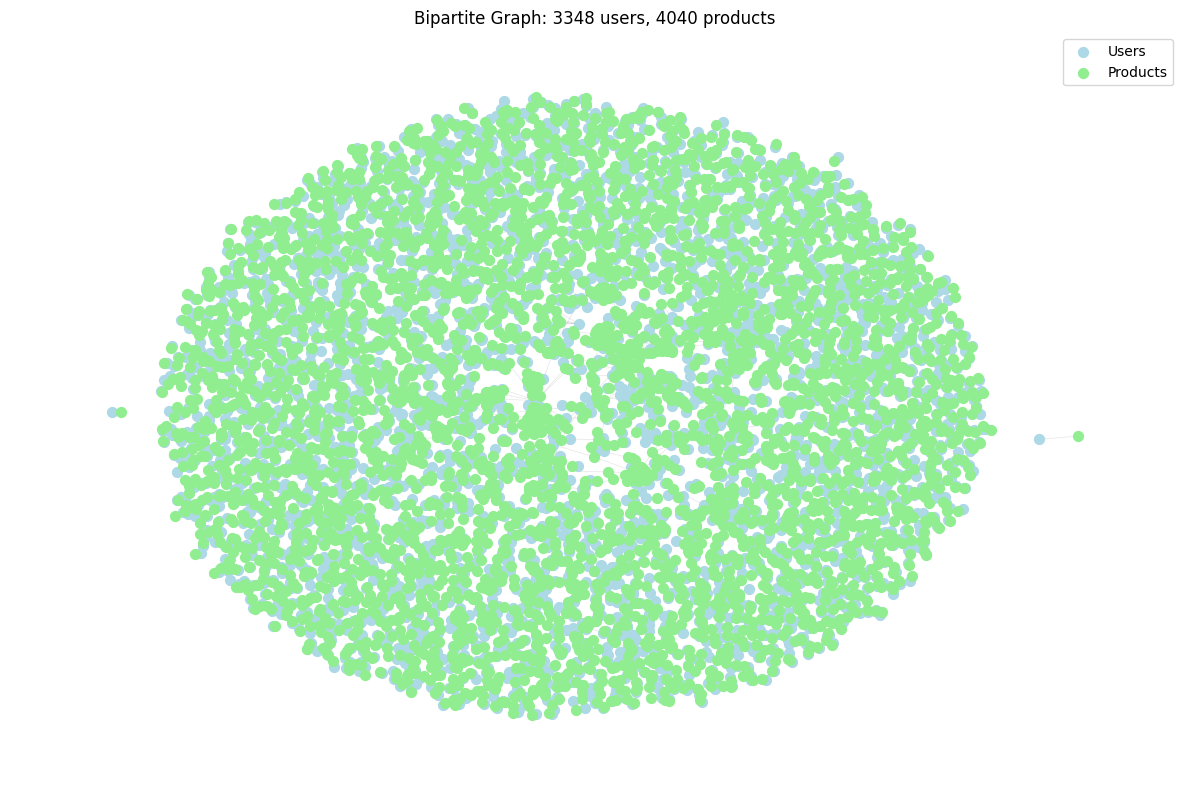

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

# Разные цвета для пользователей и товаров
user_nodes = [n for n, d in B.nodes(data=True) if d.get('type')=='user']
product_nodes = [n for n, d in B.nodes(data=True) if d.get('type')=='product']

pos = nx.spring_layout(B, k=0.5, iterations=50)

# Рисуем узлы
nx.draw_networkx_nodes(B, pos, nodelist=user_nodes, node_color='lightblue', node_size=50, label='Users')
nx.draw_networkx_nodes(B, pos, nodelist=product_nodes, node_color='lightgreen', node_size=50, label='Products')

# Рисуем ребра (можно сделать полупрозрачными)
nx.draw_networkx_edges(B, pos, alpha=0.1, width=0.5)

plt.title(f'Bipartite Graph: {len(user_nodes)} users, {len(product_nodes)} products')
plt.legend()
plt.axis('off')
plt.tight_layout()
plt.show()

Подозрительных пользователей: 3348
Подозрительных товаров: 201
Всего подозрительных узлов: 3549


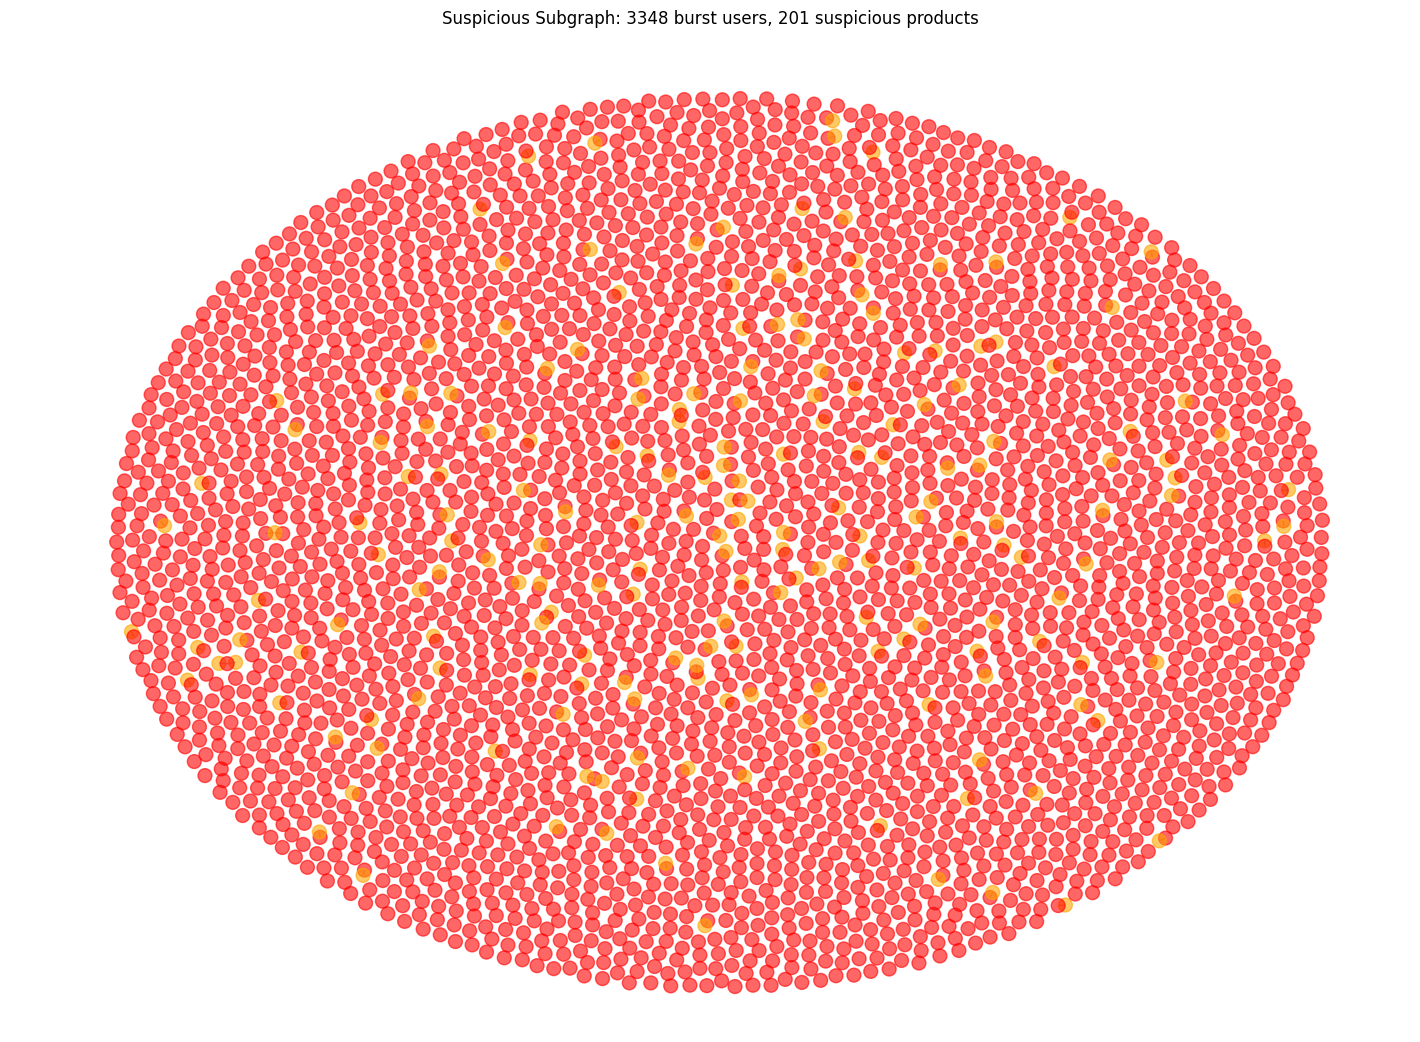

In [18]:
# Находим пользователей с burst-активностью
burst_users = df_sample[df_sample['is_burst'] == True]['user_id'].unique()

# Находим товары с подозрительной активностью
suspicious_products = []
for product in df_sample['parent_asin'].unique():
    product_reviews = df_sample[df_sample['parent_asin'] == product]
    # Товар подозрителен, если много отзывов за короткое время
    if len(product_reviews) >= 3:
        time_span = (product_reviews['timestamp'].max() - product_reviews['timestamp'].min()).total_seconds() / 3600
        if time_span < 24:  # 3+ отзыва за 24 часа
            suspicious_products.append(product)

# Создаем подграф только с подозрительными узлами
suspicious_users = burst_users.tolist()
suspicious_nodes = set(suspicious_users + suspicious_products)
B_suspicious = B.subgraph(suspicious_nodes)

print(f"Подозрительных пользователей: {len(suspicious_users)}")
print(f"Подозрительных товаров: {len(suspicious_products)}")
print(f"Всего подозрительных узлов: {len(B_suspicious.nodes())}")

# Визуализируем только подозрительную часть
if len(B_suspicious.nodes()) > 0:
    plt.figure(figsize=(14, 10))

    # Цвета: красный = burst user, оранжевый = suspicious product
    node_colors = []
    for node in B_suspicious.nodes():
        if node in burst_users:
            node_colors.append('red')
        elif node in suspicious_products:
            node_colors.append('orange')
        else:
            node_colors.append('gray')

    pos = nx.spring_layout(B_suspicious, k=1, iterations=100)
    nx.draw(B_suspicious, pos, node_color=node_colors, node_size=100,
            with_labels=False, edge_color='gray', alpha=0.6)

    plt.title(f'Suspicious Subgraph: {len(suspicious_users)} burst users, {len(suspicious_products)} suspicious products')
    plt.show()

In [19]:
from itertools import combinations

# Функция для поиска клик (полносвязных групп)
def find_coordinated_campaigns(B, df_sample, min_users=2, min_products=2):
    """
    Ищет группы пользователей, которые вместе писали отзывы на одни и те же товары
    """
    campaigns = []

    # Для каждого товара, находим всех пользователей
    product_users = {}
    for product in df_sample['parent_asin'].unique():
        users = df_sample[df_sample['parent_asin'] == product]['user_id'].tolist()
        if len(users) >= min_users:
            product_users[product] = set(users)

    # Ищем пересекающиеся группы
    checked_pairs = set()

    for product1, users1 in product_users.items():
        for product2, users2 in product_users.items():
            if product1 >= product2:
                continue

            # Общие пользователи между двумя товарами
            common_users = users1.intersection(users2)
            if len(common_users) >= min_users:
                pair_key = tuple(sorted(common_users))
                if pair_key not in checked_pairs:
                    checked_pairs.add(pair_key)

                    # Собираем всю информацию о кампании
                    campaign = {
                        'users': list(common_users),
                        'products': [product1, product2],
                        'size': len(common_users),
                        'reviews': df_sample[df_sample['user_id'].isin(common_users) &
                                            df_sample['parent_asin'].isin([product1, product2])]
                    }

                    # Анализируем временные метки
                    timestamps = campaign['reviews']['timestamp']
                    if len(timestamps) > 1:
                        time_span = (timestamps.max() - timestamps.min()).total_seconds() / 3600
                        campaign['time_span_hours'] = time_span
                    else:
                        campaign['time_span_hours'] = 0

                    # Средний рейтинг
                    campaign['avg_rating'] = campaign['reviews']['rating'].mean()

                    # Доля подтвержденных покупок
                    campaign['verified_ratio'] = campaign['reviews']['verified_purchase'].mean()

                    campaigns.append(campaign)

    # Сортируем по размеру группы
    campaigns.sort(key=lambda x: x['size'], reverse=True)
    return campaigns

# Находим кампании
campaigns = find_coordinated_campaigns(B, df_sample, min_users=2, min_products=2)

print(f"Найдено потенциальных кампаний: {len(campaigns)}")
for i, campaign in enumerate(campaigns[:10]):  # Показываем топ-10
    print(f"\nКампания {i+1}:")
    print(f"  Пользователи ({campaign['size']}): {campaign['users'][:5]}...")
    print(f"  Товары: {campaign['products']}")
    print(f"  Временной промежуток: {campaign['time_span_hours']:.1f} часов")
    print(f"  Средний рейтинг: {campaign['avg_rating']:.2f}")
    print(f"  Доля verified: {campaign['verified_ratio']:.2%}")

Найдено потенциальных кампаний: 9

Кампания 1:
  Пользователи (3): ['AF6BZODQJP6G5MGQC26MJZVFJNGA', 'AF74NKETE4HBXNUQVQP7I6UUUFFA', 'AFVJRHKZMJFPSOAGL3JZNRJSMBQA']...
  Товары: ['B00TKJRZN2', 'B00TKKMIRO']
  Временной промежуток: 31.3 часов
  Средний рейтинг: 5.00
  Доля verified: 0.00%

Кампания 2:
  Пользователи (2): ['AFTKJZUSHJF6SQHNZNCQE4EO35YA', 'AG73BVBKUOH22USSFJA5ZWL7AKXA']...
  Товары: ['B07YQ6G3LL', 'B081632HX6']
  Временной промежуток: 1608.1 часов
  Средний рейтинг: 4.75
  Доля verified: 0.00%

Кампания 3:
  Пользователи (2): ['AEMKSSCOGVOQLHVA57HSUD7TL3QA', 'AFEAV2H6WZFBFGZYGWCMS4KM7MHQ']...
  Товары: ['B00CQ16CT4', 'B00XP86KXU']
  Временной промежуток: 25679.7 часов
  Средний рейтинг: 5.00
  Доля verified: 100.00%

Кампания 4:
  Пользователи (2): ['AHPG65LKS3QKRWDUWAKZNLEK5RZQ', 'AHPG65LKS3QKRWDUWAKZNLEK5RZQ_1']...
  Товары: ['B08NTD1NM1', 'B0994HWXVV']
  Временной промежуток: 2658.3 часов
  Средний рейтинг: 5.00
  Доля verified: 0.00%

Кампания 5:
  Пользователи (2): ['

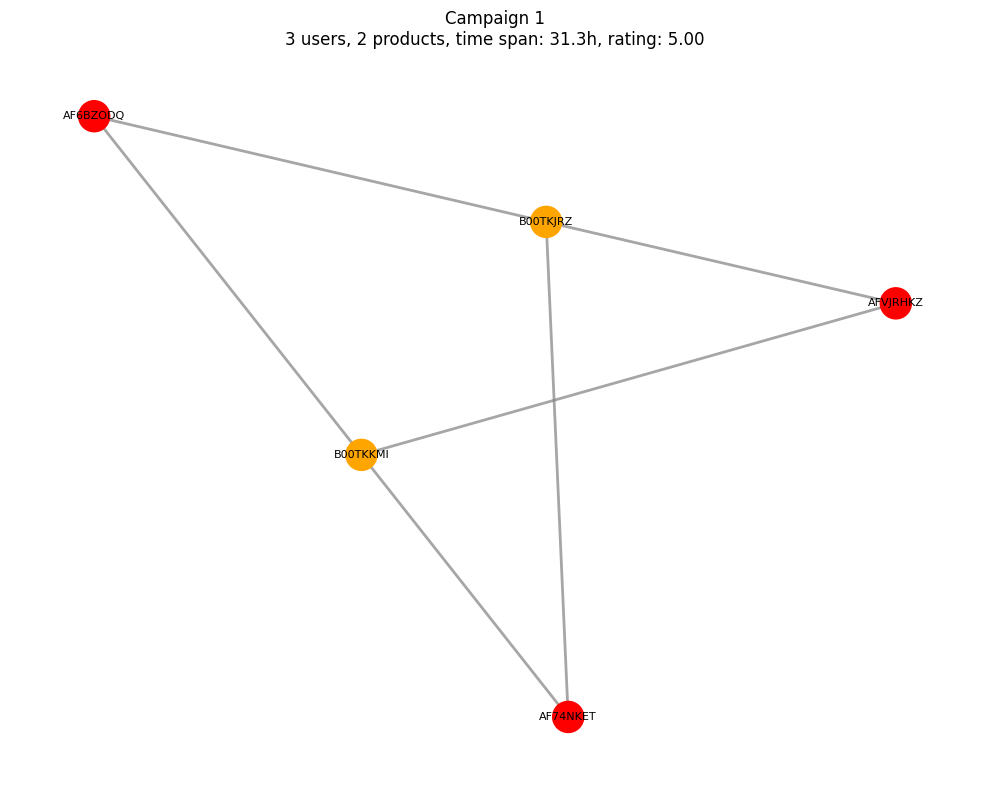

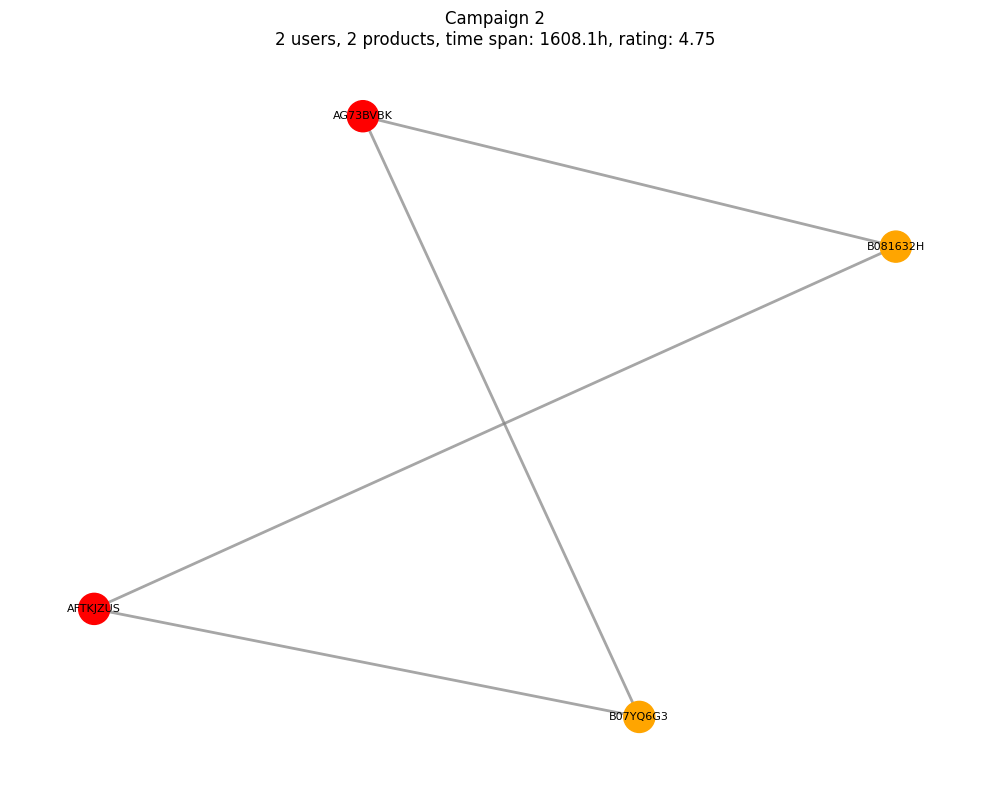

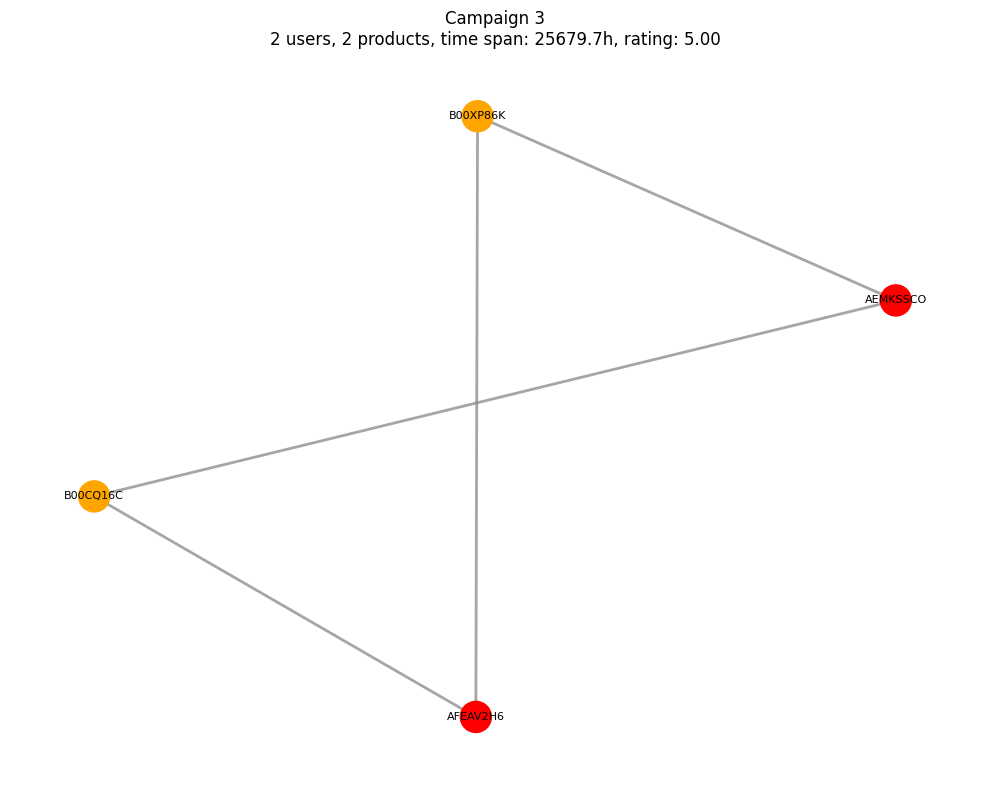

In [20]:
def visualize_campaign(B, campaign, title="Suspicious Campaign"):
    """
    Визуализирует конкретную найденную кампанию
    """
    plt.figure(figsize=(10, 8))

    # Создаем подграф для этой кампании
    nodes = set(campaign['users'] + campaign['products'])
    subgraph = B.subgraph(nodes)

    # Цвета
    node_colors = ['red' if node in campaign['users'] else 'orange' for node in subgraph.nodes()]

    pos = nx.spring_layout(subgraph, k=2, iterations=100)

    # Рисуем
    nx.draw_networkx_nodes(subgraph, pos, node_color=node_colors, node_size=500)
    nx.draw_networkx_edges(subgraph, pos, edge_color='gray', width=2, alpha=0.7)

    # Добавляем метки
    labels = {node: str(node)[:8] for node in subgraph.nodes()}
    nx.draw_networkx_labels(subgraph, pos, labels, font_size=8)

    # Добавляем информацию о кампании
    plt.title(f"{title}\n{campaign['size']} users, {len(campaign['products'])} products, "
              f"time span: {campaign['time_span_hours']:.1f}h, rating: {campaign['avg_rating']:.2f}")
    plt.axis('off')
    plt.tight_layout()
    plt.show()

# Визуализируем первые 3 найденные кампании
for i, campaign in enumerate(campaigns[:3]):
    visualize_campaign(B, campaign, f"Campaign {i+1}")

In [21]:
# Ищите паттерны вроде:
# - 2-3 пользователя
# - Пишут отзывы на 2-3 одинаковых товара
# - В течение 2-3 часов
# - Все с rating=5
# - Все с verified_purchase=False (или True, но редкое)

# Пример поиска таких групп:
from itertools import combinations

suspicious_pairs = []
for product, group in df_sample.groupby('parent_asin'):
    users = group['user_id'].tolist()
    timestamps = group['timestamp'].tolist()

    for user1, user2 in combinations(users, 2):
        # Проверяем, писали ли они в течение часа
        time_diff = abs((group[group['user_id']==user1]['timestamp'].iloc[0] -
                        group[group['user_id']==user2]['timestamp'].iloc[0]).total_seconds() / 60)

        if time_diff < 60:  # В течение часа
            suspicious_pairs.append((user1, user2, product, time_diff))